In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
import pickle


In [8]:

# ============================================================================
# LOAD DATA
# ============================================================================

# Load your 42 mutants
# Assuming format: list of sequences or list of (sequence, predicted_fitness) tuples
df = pd.read_csv('/om/user/kspiv/aurora/avGFP seqs.xlsx - IDT order.csv')
rl_mutants = df.iloc[7:,3].to_list()
DMS_PATH = '/om/user/kspiv/protein-evolution/data/Somermeyer2022_avGFP_dms_filtered.csv'
WT_PATH = '/om/user/kspiv/protein-evolution/data/avgfp_wt.txt'

# Load wildtype
with open(WT_PATH, 'r') as f:
    wt_seq = f.readline().strip()

# Load DMS data
df_dms = pd.read_csv(DMS_PATH)
# Assuming columns: 'sequence', 'fitness' or similar


In [15]:

# ============================================================================
# ANALYSIS 1: NOVELTY - Sequence Similarity to DMS
# ============================================================================

def hamming_distance(seq1, seq2):
    """Calculate Hamming distance between two sequences"""
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

def min_hamming_to_dataset(query_seq, dataset_seqs):
    """Find minimum Hamming distance from query to any sequence in dataset"""
    return min(hamming_distance(query_seq, seq) for seq in dataset_seqs)

# Calculate novelty metrics
dms_sequences = df_dms['mutated_sequence'].values  # Adjust column name
rl_sequences = rl_mutants#[m['sequence'] for m in rl_mutants]  # Adjust based on structure

novelty_metrics = []
for rl_seq in rl_sequences:
    min_dist = min_hamming_to_dataset(rl_seq, dms_sequences)
    novelty_metrics.append({
        'sequence': rl_seq,
        'min_hamming_dist': min_dist,
        'num_mutations_from_wt': hamming_distance(rl_seq, wt_seq),
        'is_in_dms': rl_seq in dms_sequences
    })

novelty_df = pd.DataFrame(novelty_metrics)

print("=" * 80)
print("NOVELTY ANALYSIS")
print("=" * 80)
print(f"RL mutants in DMS dataset: {novelty_df['is_in_dms'].sum()} / {len(novelty_df)} ({novelty_df['is_in_dms'].mean()*100:.1f}%)")
print(f"Novel mutants (not in DMS): {(~novelty_df['is_in_dms']).sum()}")
print(f"\nMinimum Hamming distance to DMS:")
print(f"  Mean: {novelty_df['min_hamming_dist'].mean():.2f}")
print(f"  Median: {novelty_df['min_hamming_dist'].median():.0f}")
print(f"  Range: [{novelty_df['min_hamming_dist'].min():.0f}, {novelty_df['min_hamming_dist'].max():.0f}]")
print(f"\nMutations from wildtype:")
print(f"  Mean: {novelty_df['num_mutations_from_wt'].mean():.2f}")
print(f"  Median: {novelty_df['num_mutations_from_wt'].median():.0f}")

# Statistical test: Are RL mutants significantly different from random sampling?
# Compare to null distribution of random DMS samples
n_bootstrap = 5
random_min_dists = []
for _ in range(n_bootstrap):
    random_sample = np.random.choice(dms_sequences, size=42, replace=False)
    dists = [min_hamming_to_dataset(seq, dms_sequences[dms_sequences != seq]) 
             for seq in random_sample]
    random_min_dists.append(np.mean(dists))
    if _ % 5 == 0:print(_)

p_value_novelty = np.mean(random_min_dists >= novelty_df['min_hamming_dist'].mean())
print(f"\nNovelty significance test (vs random DMS sampling):")
print(f"  p-value: {p_value_novelty:.4f}")


NOVELTY ANALYSIS
RL mutants in DMS dataset: 0 / 42 (0.0%)
Novel mutants (not in DMS): 42

Minimum Hamming distance to DMS:
  Mean: 3.74
  Median: 4
  Range: [1, 6]

Mutations from wildtype:
  Mean: 4.10
  Median: 4
0

Novelty significance test (vs random DMS sampling):
  p-value: 0.0000


In [20]:
fitnesses = []
import torch
import torch.nn as nn
import torch.nn.functional as F

class SurrogateNoEmbeddings(nn.Module):
    """
    Optimized MLP model for learning from raw amino acid sequences.
    """
    def __init__(self, seq_length=238, emb_dim=64, n_layers=1, n_heads=2, dropout=0.1):
        super().__init__()
        self.seq_length = seq_length
        self.emb_dim = emb_dim

        # Create mapping - use a fixed order
        aa_list = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 
                   'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y', 'X']
        self.aa_to_idx = {aa: i for i, aa in enumerate(aa_list)}
        self.unk_idx = self.aa_to_idx['X']

        self.aa_embedding = nn.Embedding(num_embeddings=len(self.aa_to_idx), embedding_dim=emb_dim)
        self.pos_embedding = nn.Embedding(seq_length, emb_dim)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=n_heads, 
            dim_feedforward=emb_dim*2, batch_first=True, dropout=dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        self.mlp_head = nn.Sequential(
            nn.Linear(seq_length * emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def encode_sequences(self, sequences):
        """
        Optimized batch encoding of sequences to indices.
        Uses vectorized operations instead of nested loops.
        """
        batch_size = len(sequences)
        device = next(self.parameters()).device
        
        # Pre-allocate output tensor
        idxs = torch.full((batch_size, self.seq_length), self.unk_idx, 
                         dtype=torch.long, device=device)
        
        # Process all sequences at once
        for i, seq in enumerate(sequences):
            seq_upper = seq.upper()
            seq_len = min(len(seq_upper), self.seq_length)
            for j in range(seq_len):
                idxs[i, j] = self.aa_to_idx.get(seq_upper[j], self.unk_idx)
        
        return idxs

    def forward(self, sequences):
        """
        Args:
            sequences (List[str]): list of protein sequences
        Returns:
            predictions: shape [B]
        """
        batch_size = len(sequences)
        device = next(self.parameters()).device

        # Encode sequences efficiently
        idxs = self.encode_sequences(sequences)

        # Embedding
        aa_emb = self.aa_embedding(idxs)  # [B, seq_length, emb_dim]
        positions = torch.arange(self.seq_length, device=device).unsqueeze(0).expand(batch_size, -1)
        pos_emb = self.pos_embedding(positions)  # [B, seq_length, emb_dim]

        x = aa_emb + pos_emb
        x = self.dropout(x)

        # Transformer encoding
        x = self.transformer_encoder(x)  # [B, seq_length, emb_dim]

        # Flatten and predict
        x = x.reshape(batch_size, -1)
        x = self.mlp_head(x).squeeze(-1)
        return x
        
Surrogate = SurrogateNoEmbeddings
surrogate = Surrogate()
SURROGATE_PATH = '/om/user/kspiv/protein-evolution/models/avgfp_dms_surrogate_noembeddings.state_dict'
if torch.cuda.is_available():
    surrogate.load_state_dict(torch.load(SURROGATE_PATH, weights_only=True))
else:
    surrogate.load_state_dict(torch.load(SURROGATE_PATH, weights_only=True, map_location=torch.device('cpu')))
surrogate.eval()

fitnesses = surrogate.forward(rl_mutants)

In [34]:

# ============================================================================
# ANALYSIS 2: PREDICTED FITNESS DISTRIBUTION
# ============================================================================

# Get predicted fitness for RL mutants (from oracle)
# Assuming you have oracle predictions
rl_fitness = fitnesses.detach().numpy().tolist()  # Adjust based on structure
dms_fitness = df_dms['DMS_score'].values  # Adjust column name

print("\n" + "=" * 80)
print("FITNESS DISTRIBUTION ANALYSIS")
print("=" * 80)

# Descriptive statistics
print(f"\nRL Mutants (n={len(rl_fitness)}):")
print(f"  Mean: {np.mean(rl_fitness):.3f}")
print(f"  Median: {np.median(rl_fitness):.3f}")
print(f"  Std: {np.std(rl_fitness):.3f}")
print(f"  Range: [{np.min(rl_fitness):.3f}, {np.max(rl_fitness):.3f}]")

print(f"\nDMS Dataset (n={len(dms_fitness)}):")
print(f"  Mean: {np.mean(dms_fitness):.3f}")
print(f"  Median: {np.median(dms_fitness):.3f}")
print(f"  Std: {np.std(dms_fitness):.3f}")
print(f"  Range: [{np.min(dms_fitness):.3f}, {np.max(dms_fitness):.3f}]")

# Statistical tests
# 1. Two-sample t-test
t_stat, p_ttest = stats.ttest_ind(rl_fitness, dms_fitness)
print(f"\nTwo-sample t-test:")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_ttest:.4f}")

# 2. Mann-Whitney U test (non-parametric)
u_stat, p_mannwhitney = stats.mannwhitneyu(rl_fitness, dms_fitness, alternative='greater')
print(f"\nMann-Whitney U test (RL > DMS?):")
print(f"  U-statistic: {u_stat:.3f}")
print(f"  p-value: {p_mannwhitney:.4f}")

# 3. Kolmogorov-Smirnov test
ks_stat, p_ks = stats.ks_2samp(rl_fitness, dms_fitness)
print(f"\nKolmogorov-Smirnov test:")
print(f"  KS-statistic: {ks_stat:.3f}")
print(f"  p-value: {p_ks:.4f}")

# 4. Effect size (Cohen's d)
cohens_d = (np.mean(rl_fitness) - np.mean(dms_fitness)) / np.sqrt(
    ((len(rl_fitness)-1)*np.var(rl_fitness) + (len(dms_fitness)-1)*np.var(dms_fitness)) / 
    (len(rl_fitness) + len(dms_fitness) - 2)
)
print(f"\nEffect size (Cohen's d): {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"  Interpretation: {effect}")

# Percentile analysis
percentiles = [50, 75, 90, 95, 99]
print(f"\nRL mutants in DMS fitness percentiles:")
for p in percentiles:
    threshold = np.percentile(dms_fitness, p)
    n_above = np.sum(rl_fitness >= threshold)
    print(f"  Above {p}th percentile: {n_above}/{len(rl_fitness)} ({n_above/len(rl_fitness)*100:.1f}%)")



FITNESS DISTRIBUTION ANALYSIS

RL Mutants (n=42):
  Mean: 3.563
  Median: 3.904
  Std: 0.839
  Range: [1.383, 4.080]

DMS Dataset (n=51744):
  Mean: 2.658
  Median: 3.287
  Std: 1.058
  Range: [1.283, 4.123]

Two-sample t-test:
  t-statistic: 5.541
  p-value: 0.0000

Mann-Whitney U test (RL > DMS?):
  U-statistic: 1901353.000
  p-value: 0.0000

Kolmogorov-Smirnov test:
  KS-statistic: 0.755
  p-value: 0.0000

Effect size (Cohen's d): 0.855
  Interpretation: large

RL mutants in DMS fitness percentiles:
  Above 50th percentile: 36/42 (85.7%)
  Above 75th percentile: 34/42 (81.0%)
  Above 90th percentile: 33/42 (78.6%)
  Above 95th percentile: 33/42 (78.6%)
  Above 99th percentile: 28/42 (66.7%)



DIVERSITY ANALYSIS

Pairwise diversity (RL mutants):
  Mean Hamming distance: 7.96
  Median: 8.00
  Range: [3, 12]

Pairwise diversity (Random DMS sample):
  Mean Hamming distance: 8.26

Diversity comparison (RL vs random DMS):
  t-statistic: -2.471
  p-value: 0.0136


/tmp/ipykernel_1830426/4060070293.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['DMS', 'RL Mutants'])


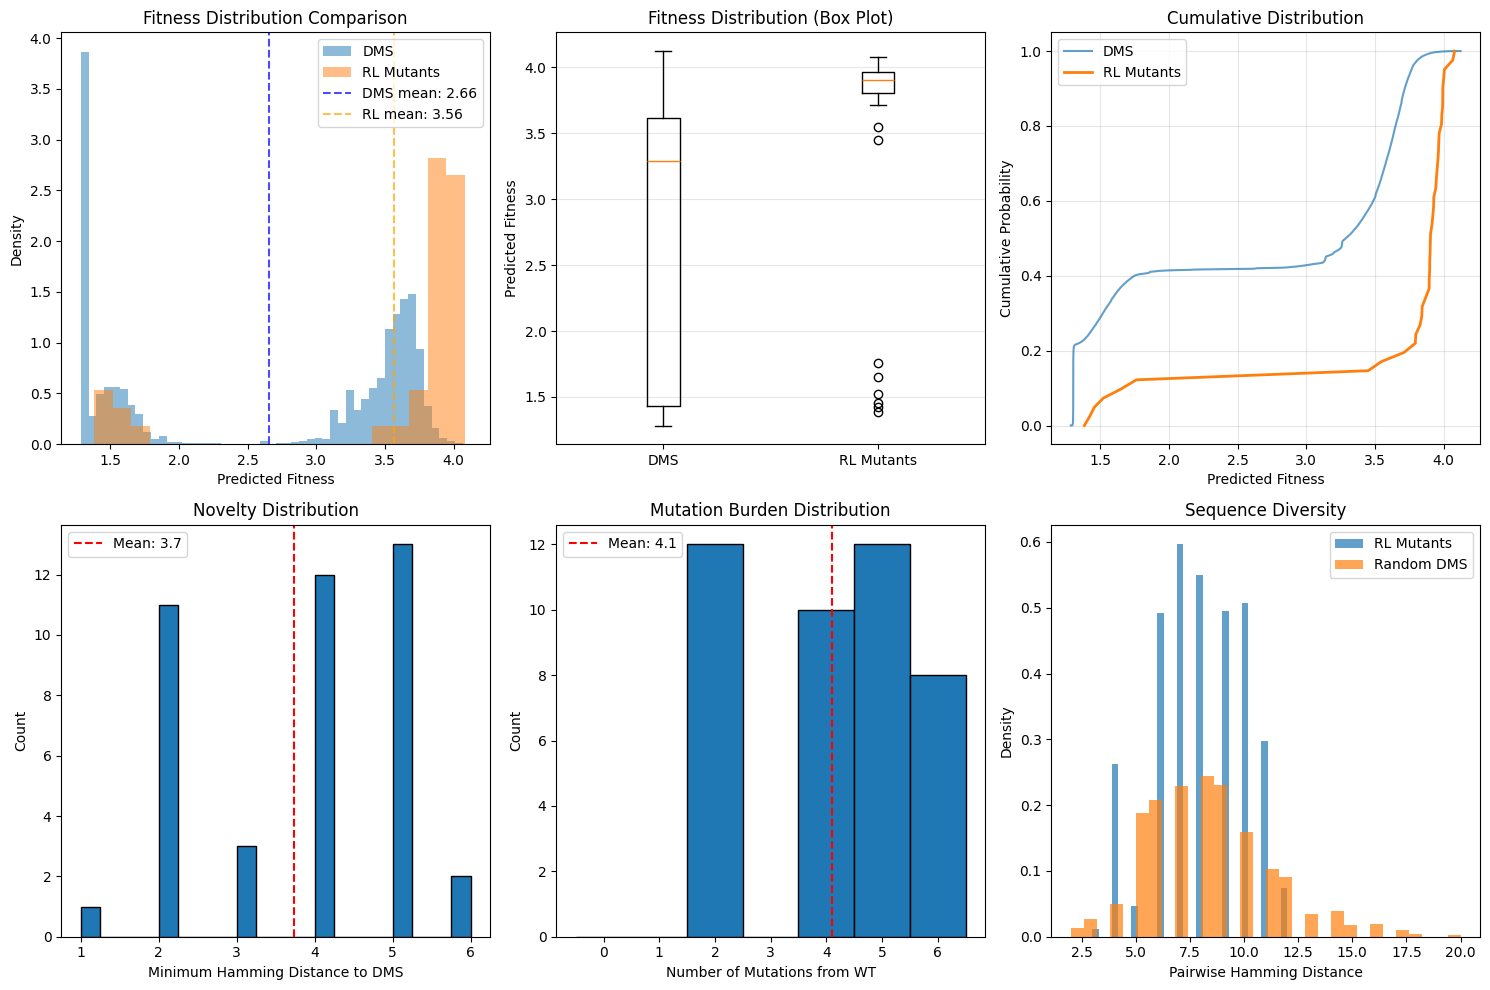

In [36]:

# ============================================================================
# ANALYSIS 3: DIVERSITY METRICS
# ============================================================================

print("\n" + "=" * 80)
print("DIVERSITY ANALYSIS")
print("=" * 80)

# Pairwise Hamming distances within RL set
rl_pairwise_dists = []
for i in range(len(rl_sequences)):
    for j in range(i+1, len(rl_sequences)):
        rl_pairwise_dists.append(hamming_distance(rl_sequences[i], rl_sequences[j]))

print(f"\nPairwise diversity (RL mutants):")
print(f"  Mean Hamming distance: {np.mean(rl_pairwise_dists):.2f}")
print(f"  Median: {np.median(rl_pairwise_dists):.2f}")
print(f"  Range: [{np.min(rl_pairwise_dists):.0f}, {np.max(rl_pairwise_dists):.0f}]")

# Compare to random DMS sample
random_dms_sample = np.random.choice(len(dms_sequences), size=42, replace=False)
random_seqs = [dms_sequences[i] for i in random_dms_sample]
random_pairwise_dists = []
for i in range(len(random_seqs)):
    for j in range(i+1, len(random_seqs)):
        random_pairwise_dists.append(hamming_distance(random_seqs[i], random_seqs[j]))

print(f"\nPairwise diversity (Random DMS sample):")
print(f"  Mean Hamming distance: {np.mean(random_pairwise_dists):.2f}")

# Test if RL diversity is significantly different
t_div, p_div = stats.ttest_ind(rl_pairwise_dists, random_pairwise_dists)
print(f"\nDiversity comparison (RL vs random DMS):")
print(f"  t-statistic: {t_div:.3f}")
print(f"  p-value: {p_div:.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Fitness distribution comparison
ax = axes[0, 0]
ax.hist(dms_fitness, bins=50, alpha=0.5, label='DMS', density=True)
ax.hist(rl_fitness, bins=20, alpha=0.5, label='RL Mutants', density=True)
ax.axvline(np.mean(dms_fitness), color='blue', linestyle='--', alpha=0.7, label=f'DMS mean: {np.mean(dms_fitness):.2f}')
ax.axvline(np.mean(rl_fitness), color='orange', linestyle='--', alpha=0.7, label=f'RL mean: {np.mean(rl_fitness):.2f}')
ax.set_xlabel('Predicted Fitness')
ax.set_ylabel('Density')
ax.set_title('Fitness Distribution Comparison')
ax.legend()

# 2. Box plot comparison
ax = axes[0, 1]
data_to_plot = [dms_fitness, rl_fitness]
ax.boxplot(data_to_plot, labels=['DMS', 'RL Mutants'])
ax.set_ylabel('Predicted Fitness')
ax.set_title('Fitness Distribution (Box Plot)')
ax.grid(axis='y', alpha=0.3)

# 3. Cumulative distribution
ax = axes[0, 2]
sorted_dms = np.sort(dms_fitness)
sorted_rl = np.sort(rl_fitness)
ax.plot(sorted_dms, np.linspace(0, 1, len(sorted_dms)), label='DMS', alpha=0.7)
ax.plot(sorted_rl, np.linspace(0, 1, len(sorted_rl)), label='RL Mutants', linewidth=2)
ax.set_xlabel('Predicted Fitness')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Cumulative Distribution')
ax.legend()
ax.grid(alpha=0.3)

# 4. Novelty distribution
ax = axes[1, 0]
ax.hist(novelty_df['min_hamming_dist'], bins=20, edgecolor='black')
ax.set_xlabel('Minimum Hamming Distance to DMS')
ax.set_ylabel('Count')
ax.set_title('Novelty Distribution')
ax.axvline(novelty_df['min_hamming_dist'].mean(), color='red', linestyle='--', 
           label=f'Mean: {novelty_df["min_hamming_dist"].mean():.1f}')
ax.legend()

# 5. Mutations from WT
ax = axes[1, 1]
ax.hist(novelty_df['num_mutations_from_wt'], bins=range(0, novelty_df['num_mutations_from_wt'].max()+2), 
        edgecolor='black', align='left')
ax.set_xlabel('Number of Mutations from WT')
ax.set_ylabel('Count')
ax.set_title('Mutation Burden Distribution')
ax.axvline(novelty_df['num_mutations_from_wt'].mean(), color='red', linestyle='--',
           label=f'Mean: {novelty_df["num_mutations_from_wt"].mean():.1f}')
ax.legend()

# 6. Pairwise diversity
ax = axes[1, 2]
ax.hist(rl_pairwise_dists, bins=30, alpha=0.7, label='RL Mutants', density=True)
ax.hist(random_pairwise_dists, bins=30, alpha=0.7, label='Random DMS', density=True)
ax.set_xlabel('Pairwise Hamming Distance')
ax.set_ylabel('Density')
ax.set_title('Sequence Diversity')
ax.legend()

plt.tight_layout()
plt.savefig('/om/user/kspiv/aurora/mutant_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


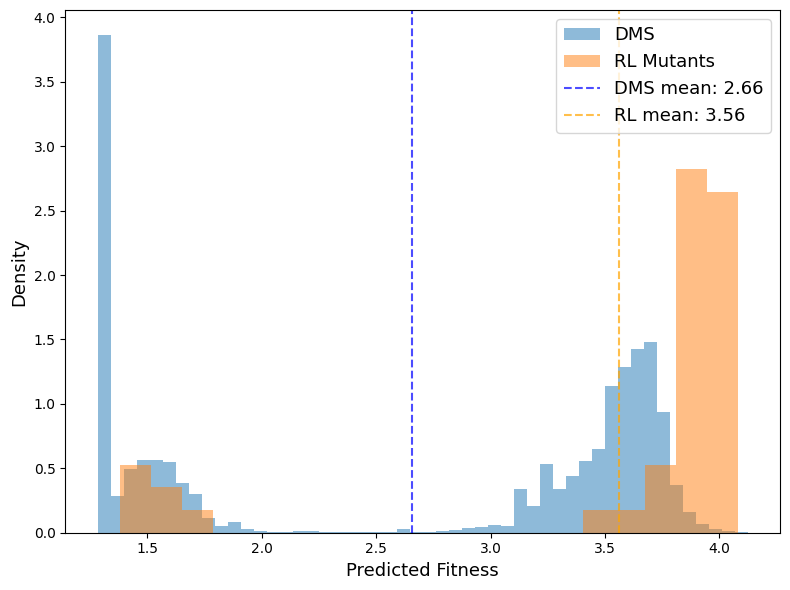

In [47]:
# Create standalone figure (not subplot)
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(dms_fitness, bins=50, alpha=0.5, label='DMS', density=True)
ax.hist(rl_fitness, bins=20, alpha=0.5, label='RL Mutants', density=True)
ax.axvline(np.mean(dms_fitness), color='blue', linestyle='--', alpha=0.7, label=f'DMS mean: {np.mean(dms_fitness):.2f}')
ax.axvline(np.mean(rl_fitness), color='orange', linestyle='--', alpha=0.7, label=f'RL mean: {np.mean(rl_fitness):.2f}')
ax.set_xlabel('Predicted Fitness', size=13)
ax.set_ylabel('Density', size=13)
# ax.set_title('Fitness Distribution Comparison')
ax.legend(fontsize=13)

plt.tight_layout()
plt.savefig('/om/user/kspiv/aurora/fitness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save statistical summary
results_summary = {
    'novelty': {
        'percent_in_dms': novelty_df['is_in_dms'].mean() * 100,
        'mean_min_hamming': novelty_df['min_hamming_dist'].mean(),
        'median_min_hamming': novelty_df['min_hamming_dist'].median(),
        'p_value': p_value_novelty
    },
    'fitness': {
        'rl_mean': np.mean(rl_fitness),
        'rl_std': np.std(rl_fitness),
        'dms_mean': np.mean(dms_fitness),
        'dms_std': np.std(dms_fitness),
        'ttest_pvalue': p_ttest,
        'mannwhitney_pvalue': p_mannwhitney,
        'cohens_d': cohens_d
    },
    'diversity': {
        'rl_mean_pairwise': np.mean(rl_pairwise_dists),
        'dms_mean_pairwise': np.mean(random_pairwise_dists),
        'diversity_pvalue': p_div
    }
}

with open('/path/to/output/results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

# Save detailed mutant information
novelty_df['predicted_fitness'] = rl_fitness
novelty_df.to_csv('/path/to/output/rl_mutants_analysis.csv', index=False)

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print(f"Results saved to /path/to/output/")